In [2]:
from langgraph.graph import StateGraph, START, MessagesState
from langgraph.checkpoint.memory import InMemorySaver
from dotenv import load_dotenv

from langchain_groq import ChatGroq
from langchain_core.messages.utils import trim_messages,count_tokens_approximately

c:\Users\Admin\Desktop\work\Agentic_AI\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
load_dotenv()

True

In [4]:
model=ChatGroq(model="llama-3.3-70b-versatile")

In [5]:
MAX_TOKEN= 150

In [6]:
def call_model(state:MessagesState):
    messages= trim_messages(
        state["messages"],
        strategy="last",
        token_counter= count_tokens_approximately,
        max_tokens= MAX_TOKEN
    )
    print("Current Token Count -> ",count_tokens_approximately(messages=messages))

    for message in messages:
        print(message.content)

    response= model.invoke(messages)

    return {"messages": [response]}

In [7]:
builder = StateGraph(MessagesState)
builder.add_node("call_model", call_model)
builder.add_edge(START, "call_model")

In [8]:

checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

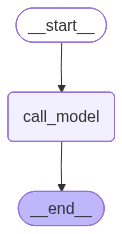

In [9]:
graph

In [14]:
config= {"configurable":{"thread_id":"chat-1"}}
result=graph.invoke(
    {"messages":[{"role":"user","content":"Hi my name is Reeya"}]},
    config   
)
result["messages"][-1].content

Current Token Count ->  9
Hi my name is Reeya


"Hello Reeya! It's nice to meet you. Is there something I can help you with or would you like to chat?"

In [15]:
result=graph.invoke(
    {"messages":[{"role":"user","content":"I am learning LangGraph"}]},
    config   
)
result["messages"][-1].content

Current Token Count ->  50
Hi my name is Reeya
Hello Reeya! It's nice to meet you. Is there something I can help you with or would you like to chat?
I am learning LangGraph


"LangGraph is a powerful tool for natural language processing and graph-based modeling. What specific aspects of LangGraph are you learning or interested in? Are you working on a project, or just exploring the technology? I'd be happy to help answer any questions you may have or provide guidance as you learn."

In [16]:
result=graph.invoke(
    {"messages":[{"role":"user","content":"Can you explain short term memory"}]},
    config   
)
result["messages"][-1].content

Current Token Count ->  146
Hi my name is Reeya
Hello Reeya! It's nice to meet you. Is there something I can help you with or would you like to chat?
I am learning LangGraph
LangGraph is a powerful tool for natural language processing and graph-based modeling. What specific aspects of LangGraph are you learning or interested in? Are you working on a project, or just exploring the technology? I'd be happy to help answer any questions you may have or provide guidance as you learn.
Can you explain short term memory


"In the context of LangGraph and natural language processing, short-term memory (STM) refers to a component that stores and manages temporary information. Here's a simplified explanation:\n\n**What is Short-Term Memory (STM)?**\n\nShort-term memory is a buffer that holds information for a short period, usually a few seconds to a minute. It's a limited-capacity storage system that allows the model to retain and manipulate information temporarily while processing input data.\n\n**How does STM work in LangGraph?**\n\nIn LangGraph, the short-term memory is used to store the following types of information:\n\n1. **Input sequences**: The input text or tokens are stored in the STM, allowing the model to process and analyze them.\n2. **Intermediate results**: The model stores intermediate results, such as attention weights, hidden states, or other temporary calculations, in the STM.\n3. **Contextual information**: The STM retains contextual information, like the conversation history or previou

In [17]:
result=graph.invoke(
    {"messages":[{"role":"user","content":"What is my name"}]},
    config   
)
result["messages"][-1].content

Current Token Count ->  8
What is my name


"I don't know your name. I'm a large language model, I don't have the ability to retain personal information about individuals, including their names. Each time you interact with me, it's a new conversation and I don't have any prior knowledge about you. If you'd like to share your name with me, I'd be happy to chat with you and use it in our conversation!"

In [19]:
for item in graph.get_state({"configurable": {"thread_id": "chat-1"}}).values['messages']:
    print(item.content)
    print('-'*120)

Hi my name is Reeya
------------------------------------------------------------------------------------------------------------------------
Hello Reeya! It's nice to meet you. Is there something I can help you with or would you like to chat?
------------------------------------------------------------------------------------------------------------------------
I am learning LangGraph
------------------------------------------------------------------------------------------------------------------------
LangGraph is a fascinating topic. It's a powerful tool for natural language processing and understanding. What specific aspects of LangGraph are you learning about? Are you working on a project, or just exploring the capabilities of the technology? I'd be happy to help answer any questions you may have or provide guidance if you need it.
------------------------------------------------------------------------------------------------------------------------
I am learning LangGraph
------